In [1]:
!pip install python-docx
from docx import Document
import copy
import numpy as np
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 3.0 MB/s eta 0:00:00


In [2]:
def get_table (document) :
  table = document.add_table(rows = 1, cols = 12, style='Table Grid')
  headers = [
        "In[0]", "In[1]", "Ac", "Z",
        "Pred", "Err",
        "CW0", "CW1", "CB",
        "UW0", "UW1", "UB"
    ]

  for i, header in enumerate(headers):
      table.rows[0].cells[i].text = header

  return table

In [3]:
class perceptron:

    def __init__(self, learning_rate = 1, output_docx = 'output.docx'):
        self.learning_rate = learning_rate
        self.weights = [1.0, 1.0]
        self.bias = 0.0
        self.max_epochs = 10
        self.boundaries = []
        self.document = Document()
        self.output_docx = output_docx

    def _activation_function(self,z):
        return 1 if z >= 0 else 0

    def _ploting(self, X, Y):
        X = np.array(X)
        Y = np.array(Y)


        for boundary in self.boundaries:

            w1 = boundary["w1"]
            w2 = boundary["w2"]
            b = boundary["b"]
            if w2 == 0: continue

            plt.scatter(X[Y == 0, 0], X[Y == 0, 1], label="Class 0")
            plt.scatter(X[Y == 1, 0], X[Y == 1, 1], label="Class 1")
            x1 = np.linspace(-2, 2, 100)
            x2 = (-w1 * x1 - b) / w2

            plt.plot(x1, x2, label = f'{w2}(x2) = {-w1} (x1) + ({-b})', color = 'r' )

            plt.xlim(-2, 2)
            plt.ylim(-2, 2)

            plt.axhline(0, color = 'k')
            plt.axvline(0, color = 'k')

            plt.xlabel("x1 --> ")
            plt.ylabel("x2 --> ")
            if boundary['x'] is None:
                plt.title(f' Final output Epoch {boundary['epoch']}')
            else:
                plt.title(f' Epoch {boundary['epoch']} for {boundary['x']}')

            plt.grid()
            plt.legend()


            plt.show()

    def fit(self, X, Y):
        for epoch in range(1,self.max_epochs+1):

            print('='*80)
            print(f'Epoch : {epoch}')
            print('='*80)
            header = f"{'X1':<2} | {'X2':<2} | {'Ac':<1} | {'Pred':<1} | {'Err':<2} | {'W_old':<14} | {'b_old':<6} | {'W_new':<14} | {'b_new':<6}"
            print(header)
            print("-" * 80)
            self.document.add_heading( f'Epoch {epoch}', level=2 )
            table = get_table(self.document)

            weight_changed = False
            for x,y in zip(X,Y):
                z = sum( w * x for w, x in zip(self.weights,x)) + self.bias
                y1 = self._activation_function(z)

                old_weights = copy.deepcopy(self.weights)
                old_bias = copy.deepcopy(self.bias)



                if(y-y1) != 0:
                    self.weights = [w + self.learning_rate*(y-y1)*xi
                                      for w ,xi in zip(self.weights,x)]
                    self.bias += self.learning_rate * (y-y1)
                    weight_changed = True
                    self.boundaries.append({
                        'w1' : self.weights[0],
                        'w2' : self.weights[1],
                        'b'  : self.bias,
                        'epoch' : epoch,
                        'x' : x
                    })

                row = f"{x[0]:<2} | {x[1]:<2} | {y:<2} | {y1:<4} | {(y-y1):<3} | {old_weights} {'':<3} | {old_bias:<6} | {self.weights} {'':<3} | {self.bias:<6}"
                print(row)
                print('.'*80)
                cells = table.add_row().cells

                cells[0].text = str(x[0])
                cells[1].text = str(x[1])

                cells[2].text = str(y)
                cells[3].text = str(z)

                cells[4].text = str(y1)
                cells[5].text = str(y-y1)

                # Current / old weights
                cells[6].text = str(old_weights[0])
                cells[7].text = str(old_weights[1])
                cells[8].text = str(old_bias)

                # Updated weights
                cells[9].text = str(self.weights[0])
                cells[10].text = str(self.weights[1])
                cells[11].text = str(self.bias)


            if not weight_changed:
                break
        if weight_changed:
            print(f'Not Converged within {self.max_epochs} epochs')
        else:
            print(f'Converged at Epoch :: {epoch} with  Weights :: {self.weights} , Bias :: { self.bias}')
        self.boundaries.append({
              'w1' : self.weights[0],
              'w2' : self.weights[1],
              'b'  : self.bias,
              'epoch' : epoch,
              'x' : None
            })

        self.document.save(self.output_docx)
        print('Geometric interpretaion: ')
        self._ploting(X,Y)

For AND gate

Epoch : 1
X1 | X2 | Ac | Pred | Err | W_old          | b_old  | W_new          | b_new 
--------------------------------------------------------------------------------
0  | 0  | 0  | 1    | -1  | [1.0, 1.0]     | 0.0    | [1.0, 1.0]     | -1.0  
................................................................................
0  | 1  | 0  | 1    | -1  | [1.0, 1.0]     | -1.0   | [1.0, 0.0]     | -2.0  
................................................................................
1  | 0  | 0  | 0    | 0   | [1.0, 0.0]     | -2.0   | [1.0, 0.0]     | -2.0  
................................................................................
1  | 1  | 1  | 0    | 1   | [1.0, 0.0]     | -2.0   | [2.0, 1.0]     | -1.0  
................................................................................
Epoch : 2
X1 | X2 | Ac | Pred | Err | W_old          | b_old  | W_new          | b_new 
--------------------------------------------------------------------------------
0  | 0  | 0  | 0    | 0   

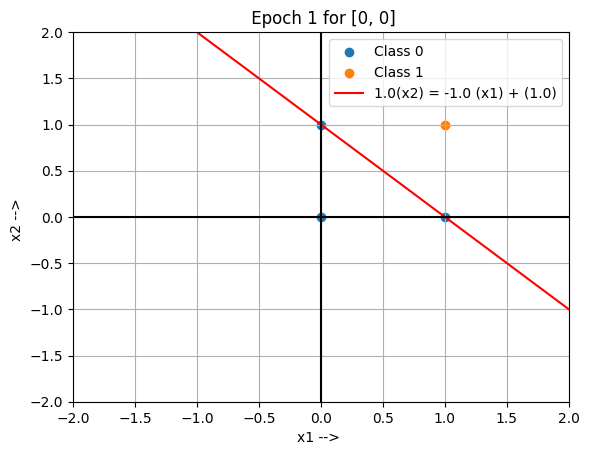

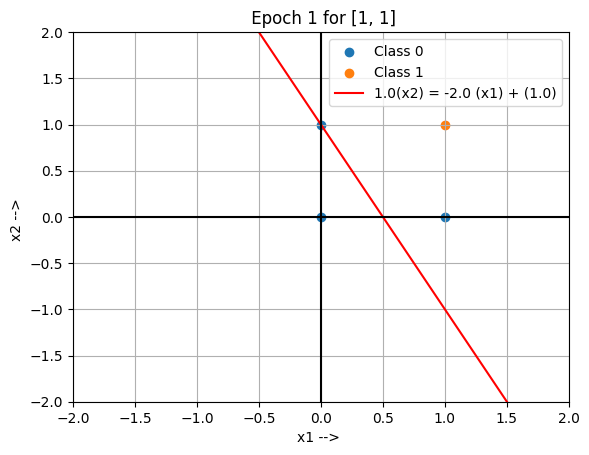

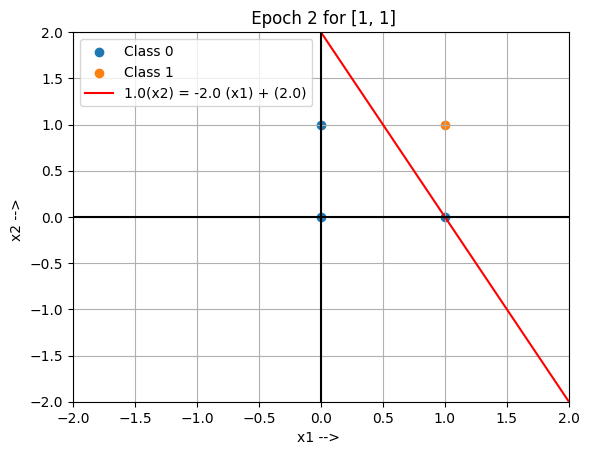

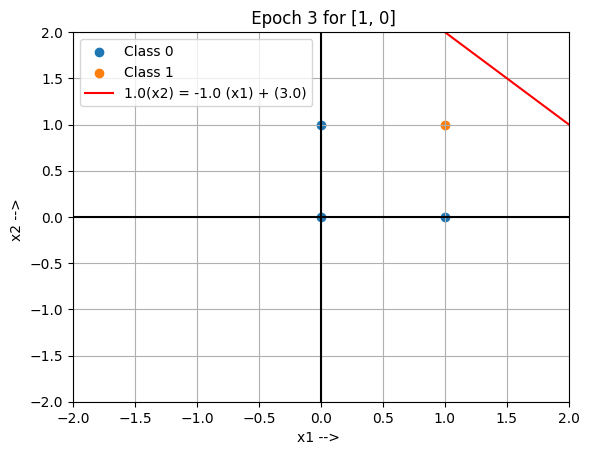

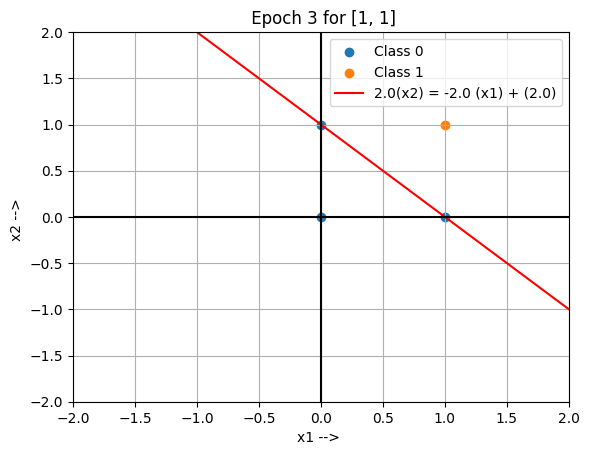

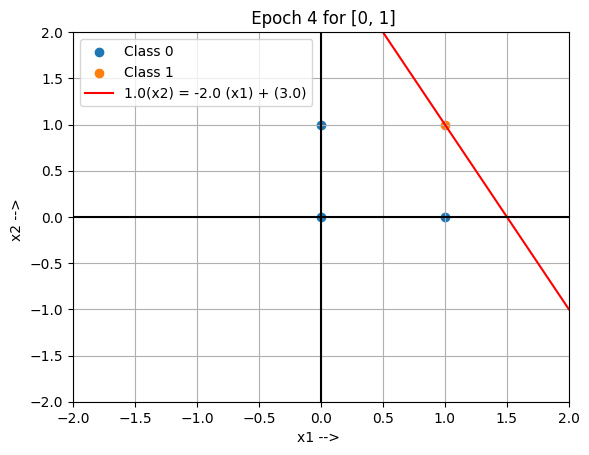

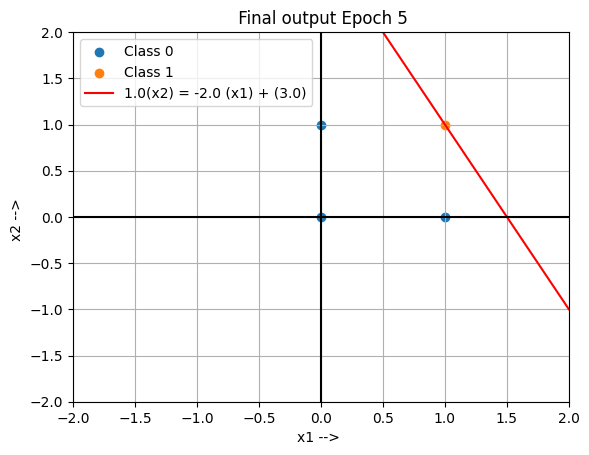

In [ ]:
p = perceptron(output_docx = 'AND.docx')
X = [[0,0],[0,1],
     [1,0],[1,1]]
Y = [0,0,0,1]
p.fit(X,Y)

For OR gate

Epoch : 1
X1 | X2 | Ac | Pred | Err | W_old          | b_old  | W_new          | b_new 
--------------------------------------------------------------------------------
0  | 0  | 0  | 1    | -1  | [1.0, 1.0]     | 0.0    | [1.0, 1.0]     | -1.0  
................................................................................
0  | 1  | 1  | 1    | 0   | [1.0, 1.0]     | -1.0   | [1.0, 1.0]     | -1.0  
................................................................................
1  | 0  | 1  | 1    | 0   | [1.0, 1.0]     | -1.0   | [1.0, 1.0]     | -1.0  
................................................................................
1  | 1  | 1  | 1    | 0   | [1.0, 1.0]     | -1.0   | [1.0, 1.0]     | -1.0  
................................................................................
Epoch : 2
X1 | X2 | Ac | Pred | Err | W_old          | b_old  | W_new          | b_new 
--------------------------------------------------------------------------------
0  | 0  | 0  | 0    | 0   

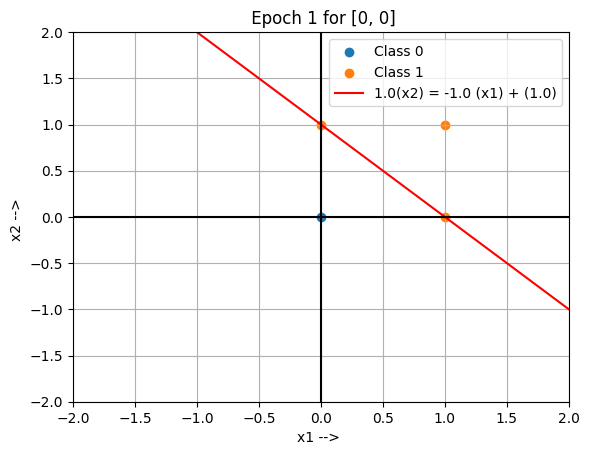

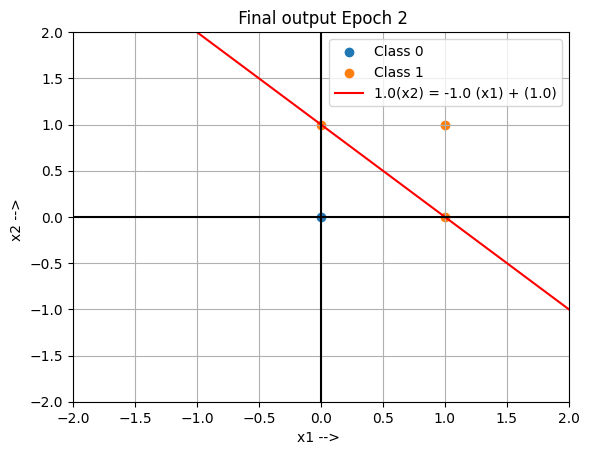

In [4]:
p = perceptron(output_docx = 'OR.docx')
X = [[0,0],[0,1],
     [1,0],[1,1]]
Y = [0,1,1,1]
p.fit(X,Y)

For XOR gate

Epoch : 1
X1 | X2 | Ac | Pred | Err | W_old          | b_old  | W_new          | b_new 
--------------------------------------------------------------------------------
0  | 0  | 0  | 1    | -1  | [1.0, 1.0]     | 0.0    | [1.0, 1.0]     | -1.0  
................................................................................
0  | 1  | 1  | 1    | 0   | [1.0, 1.0]     | -1.0   | [1.0, 1.0]     | -1.0  
................................................................................
1  | 0  | 1  | 1    | 0   | [1.0, 1.0]     | -1.0   | [1.0, 1.0]     | -1.0  
................................................................................
1  | 1  | 0  | 1    | -1  | [1.0, 1.0]     | -1.0   | [0.0, 0.0]     | -2.0  
................................................................................
Epoch : 2
X1 | X2 | Ac | Pred | Err | W_old          | b_old  | W_new          | b_new 
--------------------------------------------------------------------------------
0  | 0  | 0  | 0    | 0   

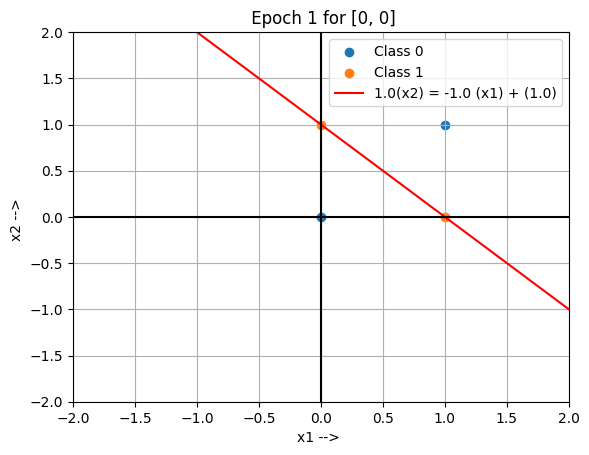

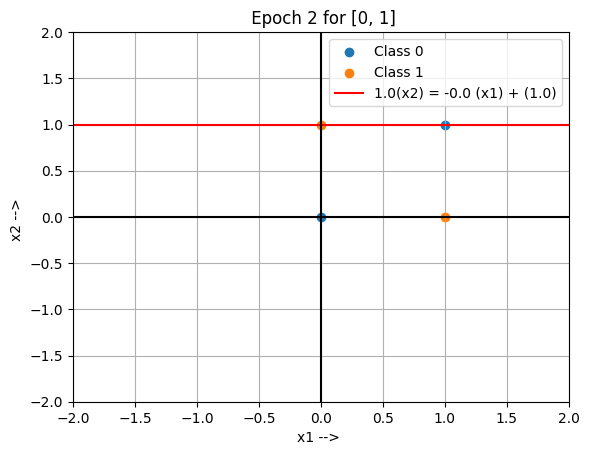

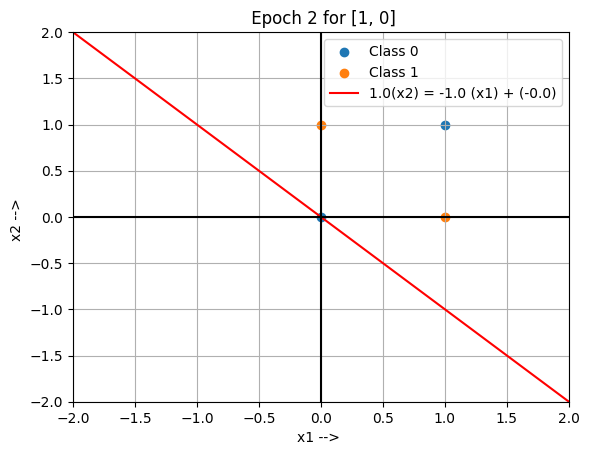

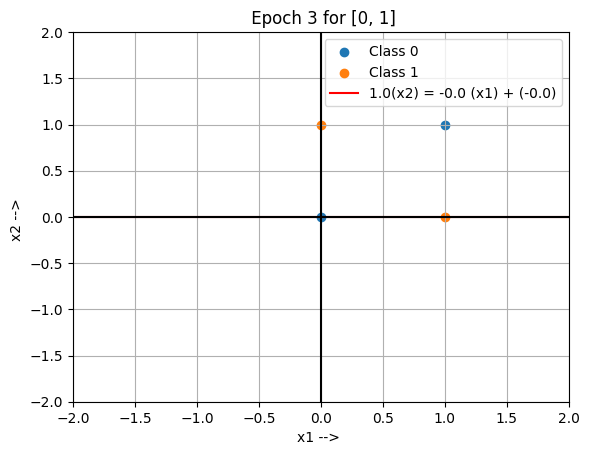

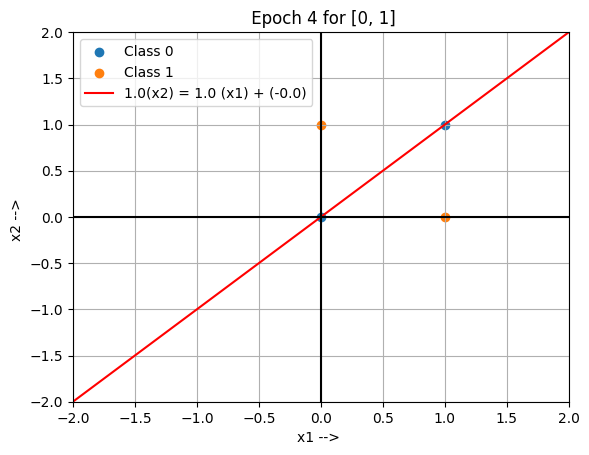

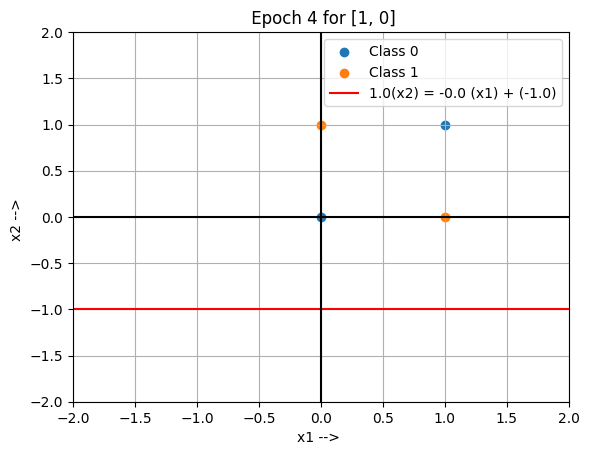

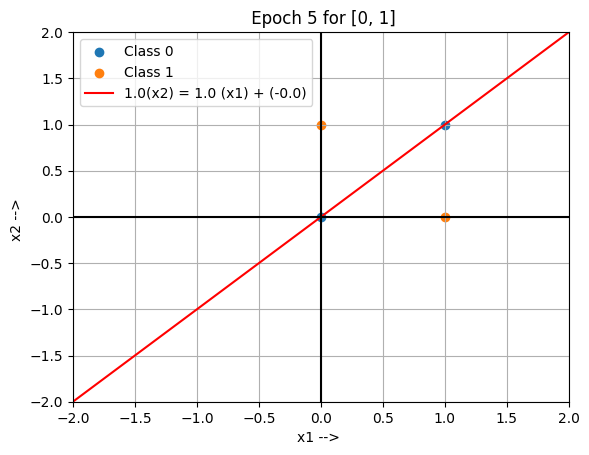

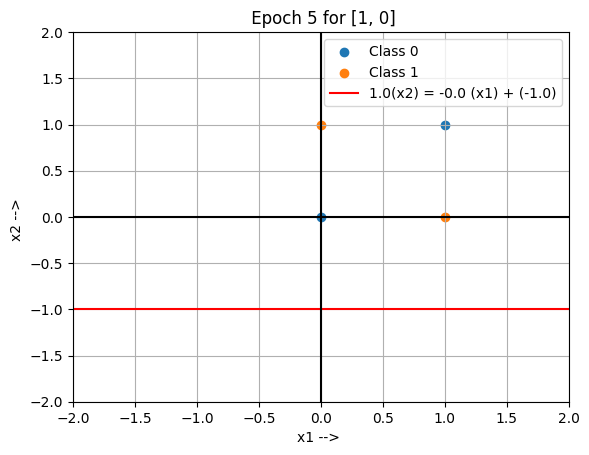

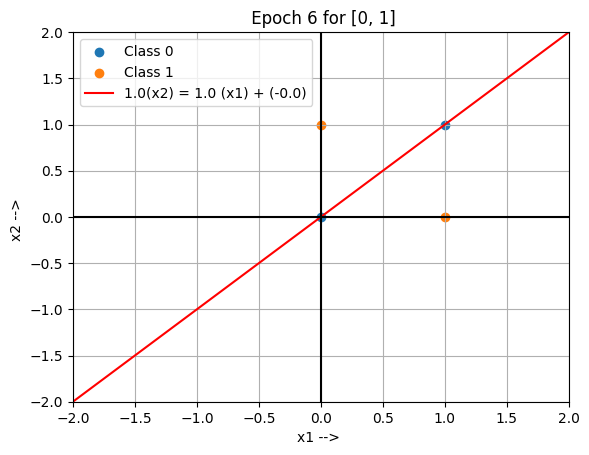

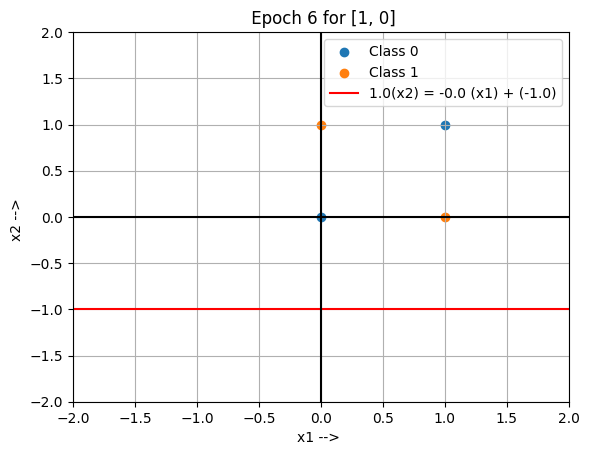

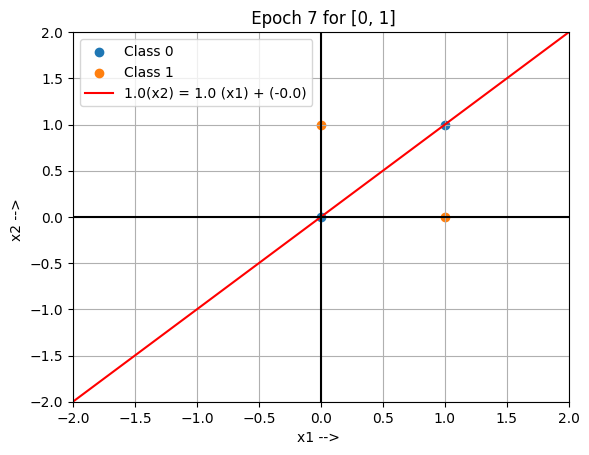

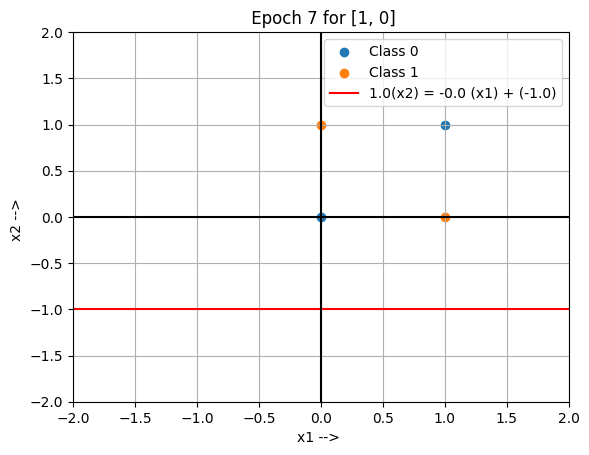

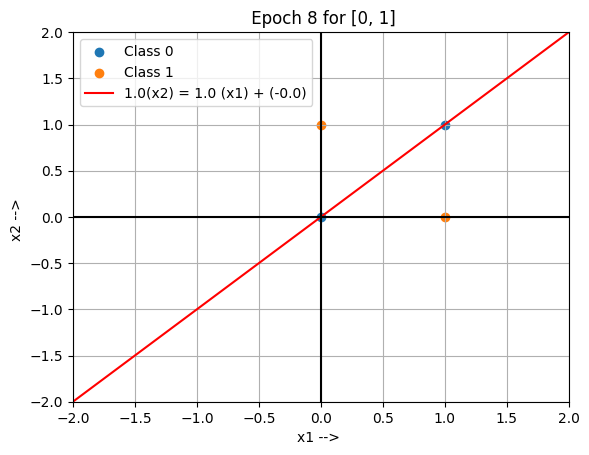

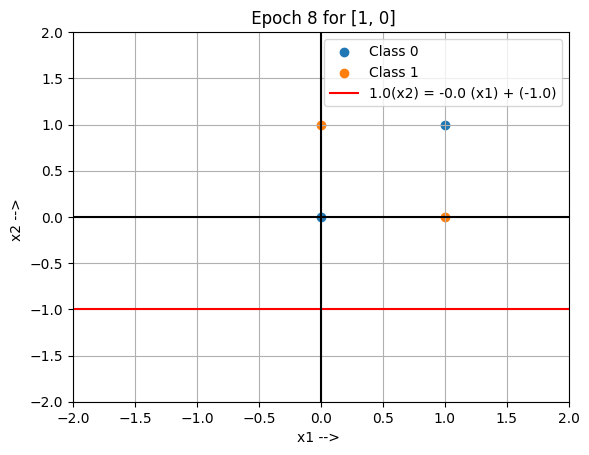

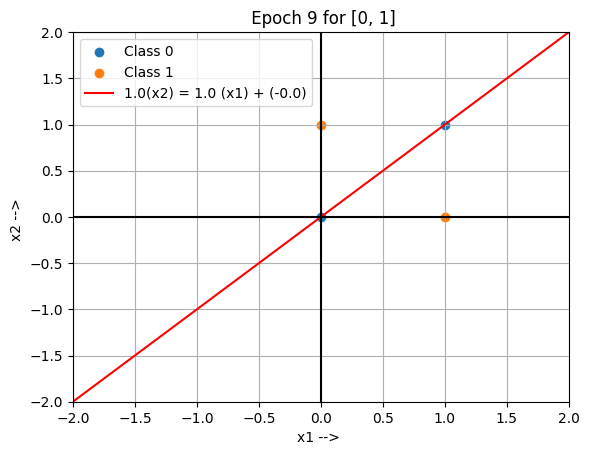

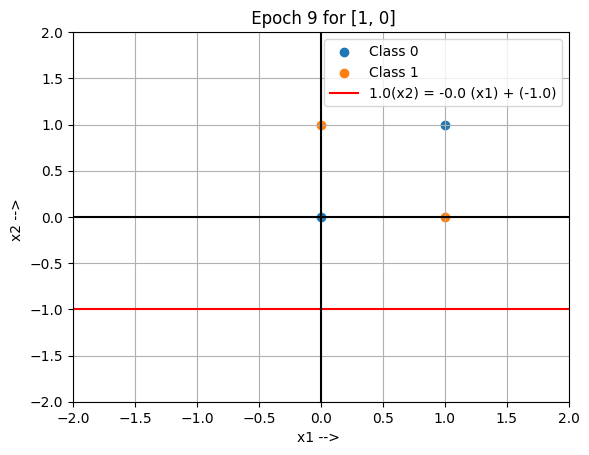

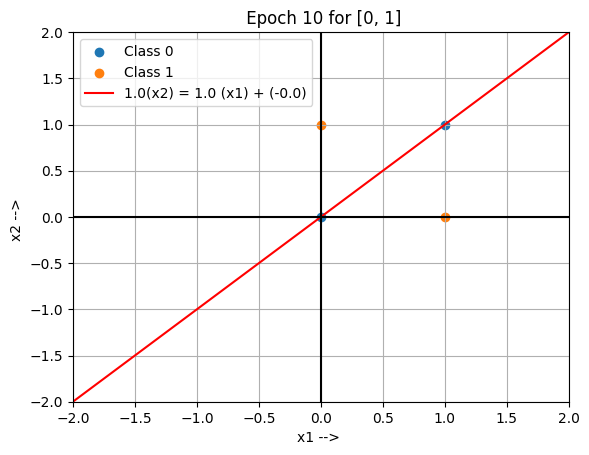

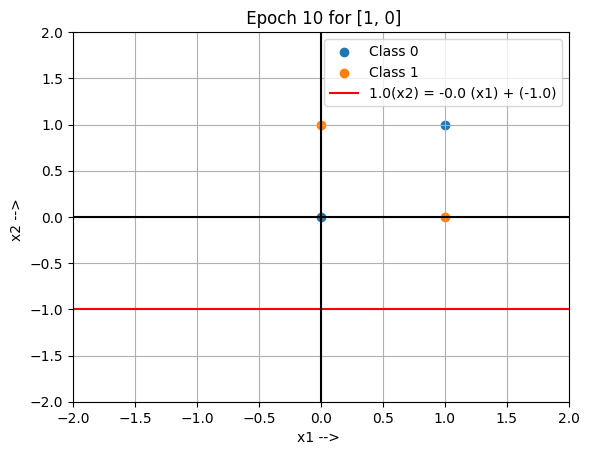

In [5]:
p = perceptron(output_docx = 'XOR.docx')
X = [[0,0],[0,1],
     [1,0],[1,1]]
Y = [0,1,1,0]
p.fit(X,Y)